In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
patients = pd.read_csv("patients.csv")
doctors = pd.read_csv("doctors.csv")
appointments = pd.read_csv("appointments.csv")
treatments = pd.read_csv("treatments.csv")
bills = pd.read_csv("billing.csv")

In [4]:
patients.head()

,patient_id,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email
0,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com
1,P002,Emily,Smith,F,1984-10-12,8228188767,321 Maple Dr,2022-01-15,PulseSecure,INS354079,emily.smith@mail.com
2,P003,Laura,Jones,M,1977-08-21,8397029847,321 Maple Dr,2022-02-07,PulseSecure,INS650929,laura.jones@mail.com
3,P004,Michael,Johnson,F,1981-02-20,9019443432,123 Elm St,2021-03-02,HealthIndia,INS789944,michael.johnson@mail.com
4,P005,David,Wilson,M,1960-06-23,7734463155,123 Elm St,2021-09-29,MedCare Plus,INS788105,david.wilson@mail.com


In [6]:
patients.tail()

,patient_id,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email
45,P046,Michael,Taylor,F,1986-09-01,8019925828,456 Oak Ave,2021-07-31,MedCare Plus,INS368799,michael.taylor@mail.com
46,P047,Jane,Moore,M,1995-12-13,8715732851,321 Maple Dr,2022-05-20,WellnessCorp,INS337549,jane.moore@mail.com
47,P048,Emily,Miller,M,1983-03-24,8720989381,123 Elm St,2023-06-19,PulseSecure,INS694319,emily.miller@mail.com
48,P049,David,Moore,M,1972-11-26,7712937941,321 Maple Dr,2023-06-14,MedCare Plus,INS584299,david.moore@mail.com
49,P050,Laura,Wilson,M,1993-12-27,8301134730,321 Maple Dr,2023-04-28,WellnessCorp,INS712210,laura.wilson@mail.com


In [7]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   patient_id          50 non-null     object
 1   first_name          50 non-null     object
 2   last_name           50 non-null     object
 3   gender              50 non-null     object
 4   date_of_birth       50 non-null     object
 5   contact_number      50 non-null     int64 
 6   address             50 non-null     object
 7   registration_date   50 non-null     object
 8   insurance_provider  50 non-null     object
 9   insurance_number    50 non-null     object
 10  email               50 non-null     object
dtypes: int64(1), object(10)
memory usage: 4.4+ KB


In [8]:
patients.isnull().sum()

patient_id            0
first_name            0
last_name             0
gender                0
date_of_birth         0
contact_number        0
address               0
registration_date     0
insurance_provider    0
insurance_number      0
email                 0
dtype: int64

In [9]:
patients.drop_duplicates(inplace = True)

In [10]:
merged_data = pd.merge(
    patients,
    appointments,
    on='patient_id'
)

In [11]:
merged_data = pd.merge(
    merged_data,
    doctors,
    on='doctor_id'
)

In [12]:
patients['patient_id'].count()

np.int64(50)

In [13]:
appointments['status'].value_counts()

status
No-show      52
Scheduled    51
Cancelled    51
Completed    46
Name: count, dtype: int64

In [14]:
bills['amount'].sum()

np.float64(551249.8500000001)

In [15]:
treatments['cost'].mean()

np.float64(2756.2492500000003)

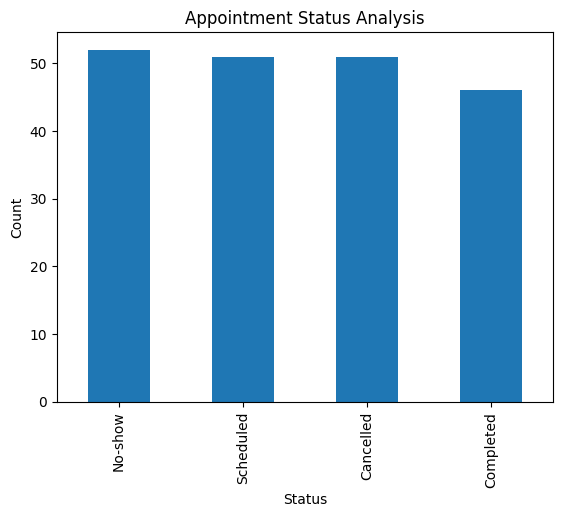

In [16]:
appointments['status'].value_counts().plot(kind = 'bar')

plt.title("Appointment Status Analysis")
plt.xlabel("Status")
plt.ylabel("Count")

plt.show()

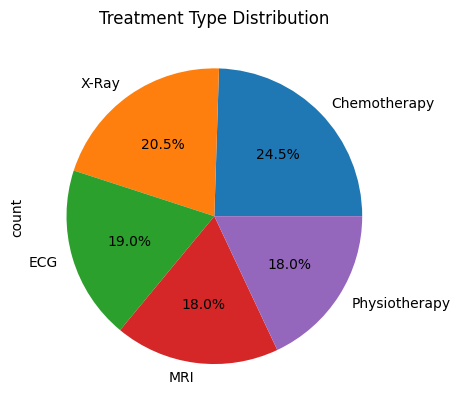

In [20]:
treatments['treatment_type'].value_counts().plot(kind = 'pie', autopct = '%1.1f%%')

plt.title("Treatment Type Distribution")

plt.show()

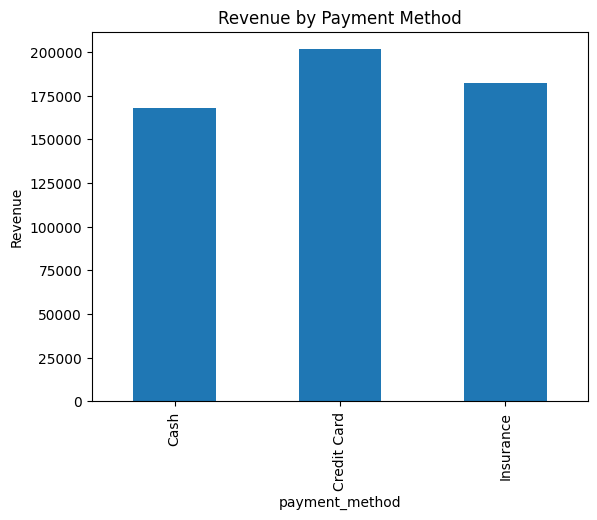

In [ ]:
bills.groupby('payment_method')['amount'].sum().plot(kind = 'bar')

plt.title("Revenue by Payment Method")
plt.ylabel("Revenue")

plt.show()

In [23]:
merged_data.to_csv("hospital_cleaned.csv", index = False)